# Mutant Moneyball: Tidy Data Cleaning & Exploratory Analysis
The mutant moneyball dataset is a dataset that tracks total comic resale value for different "X-Men" characters across four decades and four different markets.
# Project Overview:
In this project, I receive the excel dataset "mutant moneyball" and apply the "tidy data principles" to it to clean, reshape, and explore visualizations that the dataset outputs through my data tidying-up.

# 1.) Load Libraries

In [68]:
#load libraries
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# 2.) Load Data
Here, I load the raw data, and see the shape of the data: which is in the "wide format" - which means that each column is made up of two variables; in this case: "decade" and "market."

In [69]:
#load data
df_untidy = pd.read_csv('mutant_moneyball.csv')
print('Shape:', df_untidy.shape)
print('Column names:')
for col in df_untidy.columns:
    print(' ', col)

df_untidy.head()

Shape: (26, 17)
Column names:
  Member
  TotalValue60s_heritage
  TotalValue70s_heritage
  TotalValue80s_heritage
  TotalValue90s_heritage
  TotalValue60s_ebay
  TotalValue70s_ebay
  TotalValue80s_ebay
  TotalValue90s_ebay
  TotalValue60s_wiz
  TotalValue70s_wiz
  TotalValue80s_wiz
  TotalValue90s_wiz
  TotalValue60s_oStreet
  TotalValue70s_oStreet
  TotalValue80s_oStreet
  TotalValue90s_oStreet


,Member,TotalValue60s_heritage,TotalValue70s_heritage,TotalValue80s_heritage,TotalValue90s_heritage,TotalValue60s_ebay,TotalValue70s_ebay,TotalValue80s_ebay,TotalValue90s_ebay,TotalValue60s_wiz,TotalValue70s_wiz,TotalValue80s_wiz,TotalValue90s_wiz,TotalValue60s_oStreet,TotalValue70s_oStreet,TotalValue80s_oStreet,TotalValue90s_oStreet
0,warrenWorthington,929056.0,154585.0,23957.0,960.0,23335.0,3362.0,583.0,97.0,"$7,913.00","$1,105.00",$226.00,$65.75,"$68,160.00","$7,360.00",$975.00,$123.00
1,hankMcCoy,929776.0,20705.0,6631.0,881.0,23377.0,1224.0,289.0,82.0,"$7,953.00",$851.00,$89.00,$38.50,"$68,390.00","$5,260.00",$431.00,$81.00
2,scottSummers,933616.0,188635.0,29240.0,739.0,23420.0,5431.0,1031.0,82.0,"$7,993.00","$1,979.00",$438.00,$39.25,"$68,590.00","$11,675.00","$1,427.00",$74.00
3,bobbyDrake,929776.0,154585.0,1514.0,874.0,23377.0,3362.0,70.0,93.0,"$7,953.00","$1,105.00",$48.00,$62.00,"$68,390.00","$7,360.00",$137.00,$108.00
4,jeanGrey,933616.0,179899.0,16868.0,1708.0,23420.0,4903.0,665.0,170.0,"$7,993.00","$1,679.00",$165.00,$108.00,"$68,590.00","$10,265.00",$822.00,$189.00


# 3.) Missing Data Observation
Here, I look at the types of data and see that the heritage and ebay columns are stored as integer variables, while the wiz and oStreet columns are stored as strings.

Then, I see just how many pieces of data are missing from each column.

In [70]:
#observe data types and missing data
print('Data types:')
print(df_untidy.dtypes)
print('Missing values per column:')
print(df_untidy.isnull().sum())

Data types:
Member                     object
TotalValue60s_heritage    float64
TotalValue70s_heritage    float64
TotalValue80s_heritage    float64
TotalValue90s_heritage    float64
TotalValue60s_ebay        float64
TotalValue70s_ebay        float64
TotalValue80s_ebay        float64
TotalValue90s_ebay        float64
TotalValue60s_wiz          object
TotalValue70s_wiz          object
TotalValue80s_wiz          object
TotalValue90s_wiz          object
TotalValue60s_oStreet      object
TotalValue70s_oStreet      object
TotalValue80s_oStreet      object
TotalValue90s_oStreet      object
dtype: object
Missing values per column:
Member                     0
TotalValue60s_heritage    16
TotalValue70s_heritage    10
TotalValue80s_heritage     3
TotalValue90s_heritage     4
TotalValue60s_ebay        16
TotalValue70s_ebay        10
TotalValue80s_ebay         3
TotalValue90s_ebay         4
TotalValue60s_wiz         16
TotalValue70s_wiz         10
TotalValue80s_wiz          3
TotalValue90s_wiz    

# 4.) Data Cleaning and Transformation
Performed through:
1. First melting the data into long format (vs. the original wide) using df_untidy.melt
    - After melting, each row represents one "X-Man," one Decade, and one Market type
2. Splitting the variable column into "decade" and "market" using str.split()
3. Cleaning Decade column and TotalValue column with str.replace()
4. Finalizing output
    - Select the four tidy columns, drop rows where no sale value recorded, and reset index

In [71]:
#melt
df_melted = df_untidy.melt(id_vars=['Member'], var_name='variable', value_name='TotalValue')
print('Shape after melting:', df_melted.shape)
print('Sample of melted data:')
df_melted.head(10)

#split
split_cols = df_melted['variable'].str.split('_', expand=True)
df_melted['decade_raw'] = split_cols[0]
df_melted['Market'] = split_cols[1]
print('Unique decade_raw values:', df_melted['decade_raw'].unique())
print('Unique Market values:', df_melted['Market'].unique())

#clean
df_melted['Decade'] = df_melted['decade_raw'].str.replace('TotalValue', '', regex=False)
df_melted['TotalValue'] = (
    df_melted['TotalValue']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df_melted['TotalValue'] = pd.to_numeric(df_melted['TotalValue'], errors='coerce')

#finalize output
df_tidy = (
    df_melted[['Member', 'Decade', 'Market', 'TotalValue']]
    .dropna(subset=['TotalValue'])
    .reset_index(drop=True)
)

print('Final tidy shape:', df_tidy.shape)
print('Example of first couple of rows of tidy data:')
df_tidy.head(10)

Shape after melting: (416, 3)
Sample of melted data:
Unique decade_raw values: ['TotalValue60s' 'TotalValue70s' 'TotalValue80s' 'TotalValue90s']
Unique Market values: ['heritage' 'ebay' 'wiz' 'oStreet']
Final tidy shape: (284, 4)
Example of first couple of rows of tidy data:


,Member,Decade,Market,TotalValue
0,warrenWorthington,60s,heritage,929056.0
1,hankMcCoy,60s,heritage,929776.0
2,scottSummers,60s,heritage,933616.0
3,bobbyDrake,60s,heritage,929776.0
4,jeanGrey,60s,heritage,933616.0
5,alexSummers,60s,heritage,34519.0
6,lornaDane,60s,heritage,76279.0
7,seanCassidy,60s,heritage,39200.0
8,ericMagnus,60s,heritage,582934.0
9,charlesXavier,60s,heritage,819537.0


# Visualizations: Pivot Table
Table derived from total card value by "Decade" and "Market," seeing the aggregated data

In [72]:
#create pivot table
pivot_sum = df_tidy.pivot_table(
    values='TotalValue',
    index='Decade',
    columns='Market',
    aggfunc='sum'
)
pivot_sum = pivot_sum.reindex(['60s', '70s', '80s', '90s'])
print('Total Card Value by Decade and Market:')
pivot_sum.style.format('${:,.2f}')

Total Card Value by Decade and Market:


Market,ebay,heritage,oStreet,wiz
Decade,,,,
60s,"$156,977.00","$6,208,309.00","$456,785.00","$52,048.00"
70s,"$55,132.00","$2,294,491.00","$100,665.00","$16,582.00"
80s,"$14,970.00","$455,849.00","$20,089.00","$7,797.00"
90s,"$2,157.00","$20,762.00","$2,284.00","$1,494.50"


# Visualizations: Horizontal Bar Chart
This chart ranks the top 10 "X-Men" members by combined card value across all decades and markets.

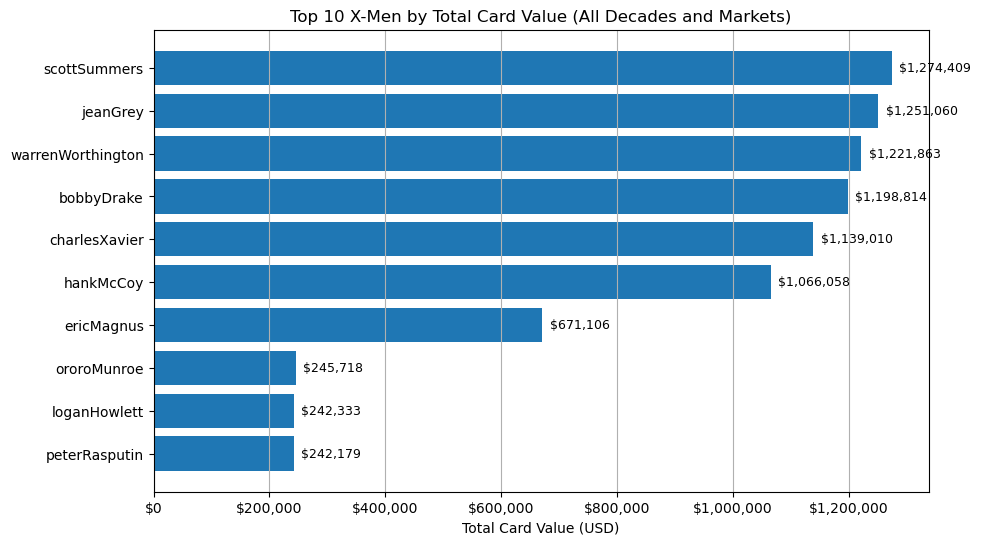

In [73]:
#create horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))

top10 = (
    df_tidy.groupby('Member')['TotalValue']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(top10)))
bars = ax.barh(top10.index, top10.values)

#put value labels at the end of each bar
for bar, val in zip(bars, top10.values):
    ax.text(
        bar.get_width() + max(top10.values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'${val:,.0f}', va='center', ha='left', fontsize=9
    )

ax.set_title('Top 10 X-Men by Total Card Value (All Decades and Markets)')
ax.set_xlabel('Total Card Value (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='x')
plt.show()

# Visualizations: Grouped Bar Chart by Decade
This chart compares total card sales across all four markets from each decade - showing how the collectibles market diminished over time

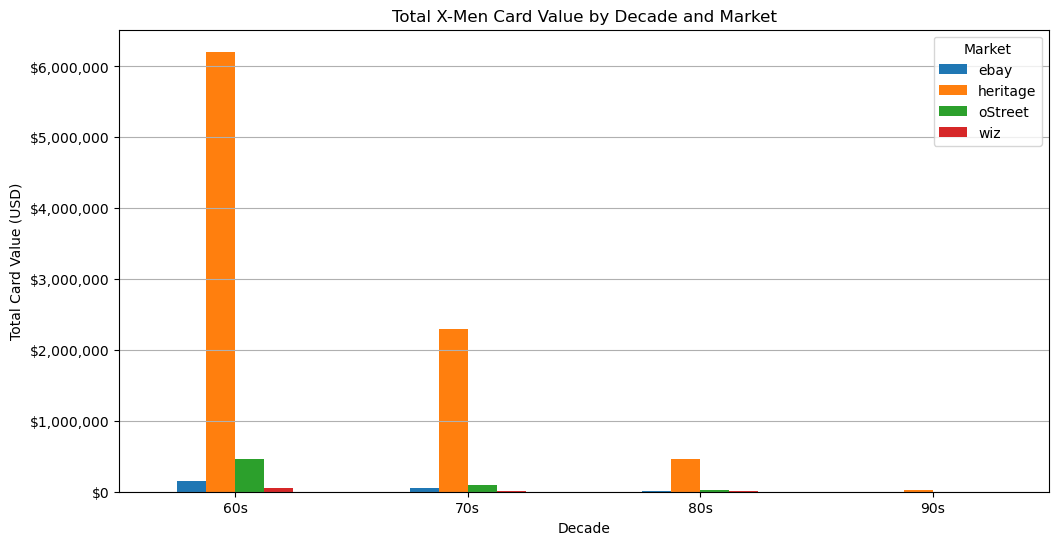

In [74]:
#create grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))

grouped = (
    df_tidy.groupby(['Decade', 'Market'])['TotalValue']
    .sum()
    .unstack()
    .reindex(['60s', '70s', '80s', '90s'])
)

grouped.plot(kind='bar', ax=ax)
ax.set_title('Total X-Men Card Value by Decade and Market')
ax.set_xlabel('Decade')
ax.set_ylabel('Total Card Value (USD)')
ax.set_xticklabels(['60s', '70s', '80s', '90s'], rotation=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Market',  loc='upper right')
ax.grid(axis='y')
plt.show()

# Tidying Summary
### Actions I performed to the "Mutant Moneyball" dataset to tidy it's data:

1.) Loaded the raw Mutant Moneyball dataset (26 members × 16 value columns in wide format)

2.) Identified untidy structure: "Decade" and "Market" were encoded in column names, not stored as values. The "wiz" and "oStreet" columns also had dollar signs and commas requiring cleanup

3.) Melted the data with pd.melt() to convert 16 columns into a long-format

4.) Split the Variable column with str.split() to make two new columns

5.) Cleaned labels and values with str.replace()

6.) Derived pivot tables from total card value by "Decade" and "Market," seeing the aggregated data

7.) Created two visualizations to better observe the dataset: a.) a horizontal bar chart that ranks the top 10 "X-Men" members by combined card value across all decades and markets and b.) a grouped bar bhart by Decade that compares total card sales across all four markets from each decade - showing how the collectibles market diminished over time

### Overall Personal Thoughts From This Process:
I saw that once the data was tidy, every analysis step became much easier to do. Even though the actual process of cleaning the data itself is really mentally taxing, once the data was cleaned, significantly better findings are able to be found, and the results are rewarding. This is the core benefit of the tidy data approach: data becomes shorter, clearer, and easier to work with.